# Grid at fixed energy varying depth of deposition
author: [Mathieu Renzo](mrenzo@arizona.edu)

In [1]:
import numpy as np
import os
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from plot_aux import (SNEC_output_parser, plot_LC, plot_vel_mass_at_time_t,
                      get_radius_at_time_for_m, get_shock_pos,
                      get_times, plot_vel_radius_at_time_t,
                      plot_rho_pfile, get_innerBC_t, get_src_col)
import astropy.units as u
import re
import glob
from itertools import cycle
from matplotlib.colors import LinearSegmentedColormap
import glob
%load_ext autoreload
%autoreload 2


Hardcoded some constants


In [5]:
def get_bomb_spread(folder):
    spread = np.nan
    fname = folder+'/parameters'
    with open(fname, 'r') as f:
        for i, line in enumerate(f):
            if line.startswith("#"): continue
            if ("bomb_mass_spread" in line):
                # print(line)
                found = re.search(r'=\s*([\d.]+(?:[deDE][+-]?\d+)?)', line)
                if found:
                    spread = float(found.group(1).replace('d', 'e').replace('D', 'e'))
                break
    return spread * u.Msun

for b in models:
    print(get_bomb_spread(b))

0.2 solMass
2.5 solMass
5.0 solMass
9.0 solMass
10.6 solMass


In [4]:
fig_folder = "../manuscript/figures/"
root = "/home/mrenzo/Runs/LMXRB/SNEC_expl/"
bombs_root = root+"/farmer23/bomb_spread/"
models = sorted(glob.glob(bombs_root+'/*/'), key=get_bomb_spread)
print(len(models))

5


In [6]:
rl1 = 2.62e11*u.cm
mtot = 12.12*u.Msun
mhe_progenitor = mtot
mco_progenitor = 4.97*u.Msun
rco_progenitor = 0.08172136551192985*u.Rsun

/home/mrenzo/Documents/Research/codes/miniforge3/envs/LMXRB/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  func(*args, **kwargs)
/home/mrenzo/Documents/Research/codes/miniforge3/envs/LMXRB/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.canvas.print_figure(bytes_io, **kw)


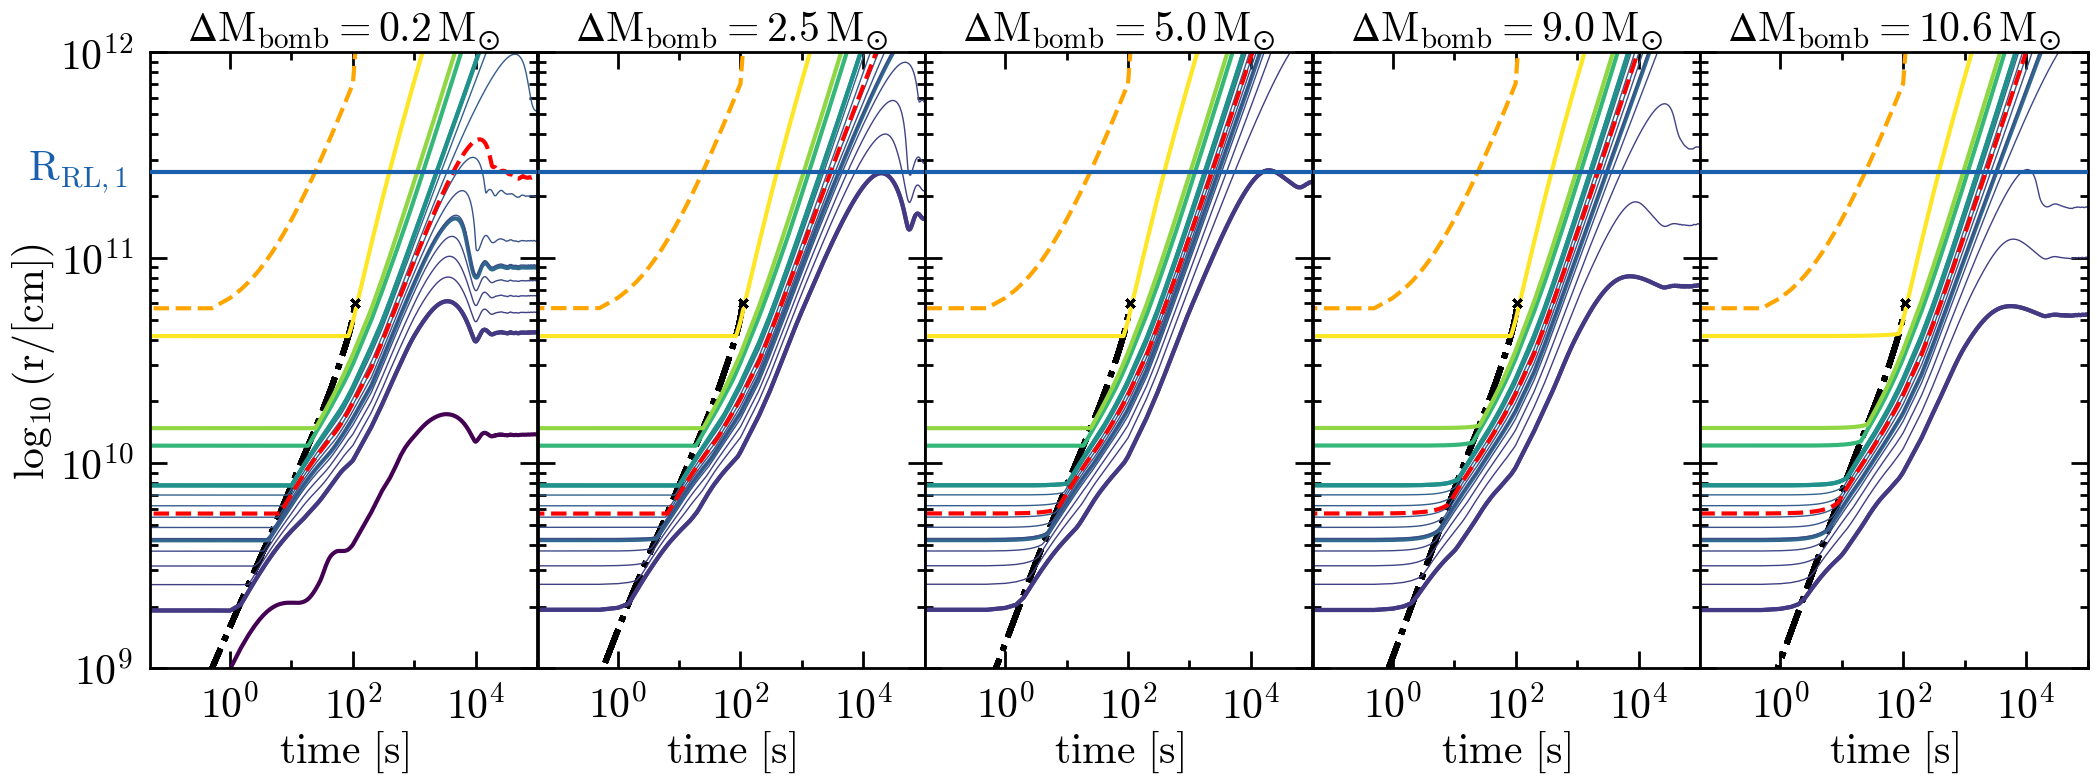

In [8]:
fig = plt.figure(figsize=(5 * len(models), 8))
gs = gridspec.GridSpec(100, 250 * len(models))
axes = {}
for i in range(len(models)):
    axes[i] = fig.add_subplot(gs[:, i*250:(i+1)*250])

masses = np.asarray([1.5, 2.5, 4, 6, 8, 9, 12.0], dtype=float) # np.linspace(1.5, 12, 10)# 
ii = 1
minimasses = np.linspace(masses[ii], masses[ii+2], 10)
allmasses = sorted(np.concatenate((masses, minimasses)))
colors = plt.cm.viridis(np.linspace(0, 1, len(masses)))
cmap = LinearSegmentedColormap.from_list("custom", [colors[ii], colors[ii+1]])
colorsmini = cmap(np.linspace(0,1,len(minimasses)))


for k, mod in enumerate(models):
    ax = axes[k]
    for i, m in enumerate(allmasses): 
        t, r = get_radius_at_time_for_m(mod+'Data/mass.xg', mcoord=m*u.Msun)
        x, y = t.to(u.s).value, r.to(u.cm).value
        if ((m in minimasses) and (m not in masses)):
            lw = 1
            color = colorsmini[np.argmin(np.absolute(minimasses-m))]
        else:
            lw=3
            color=colors[np.argmin(np.absolute(masses-m))]
        ax.plot(x, y, c=color, lw=lw)
        # find shock
        i_shock, t_shock, r_shock = get_shock_pos(mod)
        ax.plot(t_shock.to(u.s), r_shock.to(u.cm), c='k', lw=4, ls='-.', zorder=0)
        ax.plot(t_shock.to(u.s)[-1], r_shock.to(u.cm)[-1], c='k', zorder=10, marker='x')
    # add He core mass
    t, r = get_radius_at_time_for_m(mod+'Data/mass.xg', mcoord=mhe_progenitor)
    x, y = t.to(u.s).value, r.to(u.cm).value
    ax.plot(x, y, c='orange', lw=3, ls='--')

    # add CO core mass
    t, r = get_radius_at_time_for_m(mod+'Data/mass.xg', mcoord=mco_progenitor)
    x, y = t.to(u.s).value, r.to(u.cm).value
    ax.plot(x, y, c='r', lw=3, ls='--')

    # ax.text(x[0]*1.05, y[0], r"  $M_{\rm He}$  ", size=15, color='k',
    #         ha="right" , bbox=dict(boxstyle="round,pad=0.02",
    #                                facecolor="white", edgecolor="w", alpha=1.))            
    # ax.text(x[0]*1.05, y[0], r"  $M_{\rm CO}$  ", size=15, color='r',
    #         ha="right" , bbox=dict(boxstyle="round,pad=0.02",
    #                                facecolor="white", edgecolor="white", alpha=1))
    # mark Roche lobe donor
    ax.axhline(rl1.value, 0, 1, c='#1A5FAB', zorder=10)
    ax.set_xlabel(r"$time\ [s]$")
    ax.set_xscale('log')
    ax.set_xlim(5e-2, 1e5)
    ax.set_yscale('log')
    if k==0:
        ax.text(-0.01, rl1.value,                          # -0.01 in axes fraction = just left of spine
                r"$R_{\rm RL,1}$  ",
                color='#1A5FAB',
                va="center",
                ha="right",
                fontsize=30,
                transform=ax.get_yaxis_transform())
    else:
        ax.set_yticklabels([])
        if k==len(axes)-1:
            for m in masses:
                color=colors[np.argmin(np.absolute(masses-m))]
                ax.plot(np.nan, np.nan, label=f"{m:.1f}"+r"$M_{\odot}$", color=color)

    ax.set_xticks([1e0, 1e2, 1e4])
    ax.set_xticks([1e1, 1e3, 1e5], minor=True)
    ax.set_xticklabels([], minor=True)
    
    # ax.text(1.01, 0.5, r"$E_{\rm expl}=$"+f"{sci_to_latex(get_energy_from_folder(mod))} ergs",
    #     size=30, transform=ax.transAxes, ha="left", va="center", rotation=90)
    # ax.text(0.55, 0.1, r"$E_{\rm expl}$="+f"{sci_to_latex(get_energy_from_folder(mod))}  ergs",
    #         size=30, transform=ax.transAxes, ha="center", va="bottom",
    #         # bbox=dict(boxstyle="round,pad=0.02", facecolor="white", edgecolor="#808080", alpha=0.8),
    #         zorder=k)
    ax.set_title(r"$\Delta M_{\rm bomb}="+
                 f"{get_bomb_spread(mod).value:.1f}"+
                 r"\,M_{\odot}$", size=30)
    ax.set_ylim(1e9, 1e12)
    

axes[0].set_ylabel(r"$\log_{10}(r/\mathrm{[cm]})$")
handles, labels = axes[3].get_legend_handles_labels()
axes[3].legend(handles[::-1], labels[::-1], fontsize=15, loc="lower right", handletextpad=0.1, handlelength=0.75)
